## Laboratorio 3: Detección de malware

Primero vamos a determinar si los archivos están empaquetados

In [3]:
import pefile
import os
import subprocess
import pandas as pd
import datetime
from sklearn.feature_extraction.text import TfidfVectorizer
def show_sections(pefile_object):
    for section in pefile_object.sections:
        print("Nombre:", section.Name)
        print("VirtualAddress:", hex(section.VirtualAddress))
        print("Size:", section.SizeOfRawData)
        print("-" * 20)


carpeta = "MALWR"
archivos_procesados = 0

for archivo in os.listdir(carpeta):
    ruta = os.path.join(carpeta, archivo)

    # Solo archivos normales
    if os.path.isfile(ruta):
        try:
            print("\n" + "="*60)
            print(f"Analizando: {archivo}")
            print("="*60)

            pe = pefile.PE(ruta)
            show_sections(pe)

            archivos_procesados += 1

            if archivos_procesados >= 5:
                break

        except Exception as e:
            print(f"No es un PE válido: {archivo}")

if archivos_procesados == 0:
    print("No se encontraron ejecutables PE válidos.")


FileNotFoundError: [Errno 2] No such file or directory: 'MALWR'

Vemos que si están empaquetados, vamos a desempaquetarlos

In [ ]:
for file in os.listdir('MALWR'):
    route = os.path.join('MALWR', file)
    result = subprocess.run(['upx', '-d', route], capture_output=True, text=True)

    if result.returncode == 0:
        print(f' {file} comprimido')
    else:
        print(f'{file} falló: {result.stderr}')

F6655E39465C2FF5B016980D918EA028 falló: upx: MALWR/F6655E39465C2FF5B016980D918EA028: NotPackedException: not packed by UPX

FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2 falló: upx: MALWR/FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2: NotPackedException: not packed by UPX

65018CD542145A3792BA09985734C12A falló: upx: MALWR/65018CD542145A3792BA09985734C12A: NotPackedException: not packed by UPX

6FAA4740F99408D4D2DDDD0B09BBDEFD falló: upx: MALWR/6FAA4740F99408D4D2DDDD0B09BBDEFD: NotPackedException: not packed by UPX

F8437E44748D2C3FCF84019766F4E6DC falló: upx: MALWR/F8437E44748D2C3FCF84019766F4E6DC: NotPackedException: not packed by UPX

B98hX8E8622C393D7E832D39E620EAD5D3B49 falló: upx: MALWR/B98hX8E8622C393D7E832D39E620EAD5D3B49: NotPackedException: not packed by UPX

SAM_B659D71AE168E774FAAF38DB30F4A84 falló: upx: MALWR/SAM_B659D71AE168E774FAAF38DB30F4A84: NotPackedException: not packed by UPX

POL55_A4F1ECC4D25B33395196B5D51A06790 falló: upx: MALWR/POL55_A4F1ECC4D25B33395196B5D51A06790: NotPa

Ya desempaquetados, vamos a crear el dataset, este tendrá estas características:

- Hash del archivop
- Imports
- Timestamp de compliación


In [ ]:
def get_imports(path):
    """
    Extract function calls from header
    """
    imports = set()
    timestamp = None
    try:
        pe = pefile.PE(path)
        timestamp = pe.FILE_HEADER.TimeDateStamp

        if hasattr(pe, "DIRECTORY_ENTRY_IMPORT"):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                dll = entry.dll.decode(errors="ignore")

                for imp in entry.imports:
                    if imp.name:
                        func = imp.name.decode(errors="ignore")
                        imports.add(f"{dll}:{func}")

    except pefile.PEFormatError:
        return set(), None

    except Exception:
        return set(), None

    return imports, timestamp


df =  pd.DataFrame(columns=['hash', 'imports', 'timestamp'])

for file in os.listdir('MALWR'):
    route = os.path.join('MALWR', file)
    imports, timestamp = get_imports(route)

    imports = ' '.join(list(imports))

    new_row = pd.DataFrame([{'hash': file, 'imports': imports, 'timestamp': timestamp }])

    df = pd.concat([df, new_row], ignore_index=True)

    if result.returncode == 0:
        print(f' {file} comprimido')
    else:
        print(f'{file} falló: {result.stderr}')


df.to_csv('raw_data.csv')

F6655E39465C2FF5B016980D918EA028 falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2 falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

65018CD542145A3792BA09985734C12A falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

6FAA4740F99408D4D2DDDD0B09BBDEFD falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

F8437E44748D2C3FCF84019766F4E6DC falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

B98hX8E8622C393D7E832D39E620EAD5D3B49 falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

SAM_B659D71AE168E774FAAF38DB30F4A84 falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14FC7E: NotPackedException: not packed by UPX

POL55_A4F1ECC4D25B33395196B5D51A06790 falló: upx: MALWR/QW2_4C6BDDCCA2695D6202DF38708E14

## Preprocesamiento

Vamos a usar TF-IDF para convertir la secuencia de imports a vectores

In [ ]:
df_malware = pd.read_csv('raw_data.csv', index_col = 0)

print('Numero de filas: ', df_malware.shape[0])

# Fit and tran

Numero de filas:  41


In [ ]:
df_malware.isna().sum()

hash         0
imports      1
timestamp    1
dtype: int64

Vemos que tenemos un archivo del cuál no hay ni imports ni timestamp, vamos a borrarlo pues la forma en la que pensamos analizar el malware es en base a los imports en la sección del header.

In [ ]:
df_malware = df_malware.dropna(subset=['imports'])

df_malware.isna().sum()

hash         0
imports      0
timestamp    0
dtype: int64

In [ ]:
def count_unique_imports(df, column="imports"):
    unique_imports = set()

    for row in df[column].dropna():
        imports = row.split()
        unique_imports.update(imports)

    return len(unique_imports), unique_imports

n_imports, imports_set = count_unique_imports(df_malware)

print("Número de imports únicos:", n_imports)

Número de imports únicos: 393


Y ahora vamos a vectorizar con TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()

corpus = list(df_malware['imports'])

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

df_new = pd.DataFrame({
    'Hash': df_malware['hash'],
    'Imports': list(tfidf_matrix.toarray()),
    'Timestamp': df_malware['timestamp']
})

print(df_new.head())



                                       Hash  \
0          F6655E39465C2FF5B016980D918EA028   
1  FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2   
2          65018CD542145A3792BA09985734C12A   
3          6FAA4740F99408D4D2DDDD0B09BBDEFD   
4          F8437E44748D2C3FCF84019766F4E6DC   

                                             Imports     Timestamp  
0  [0.0, 0.0, 0.0, 0.018760568151320798, 0.0, 0.0...  1.263576e+09  
1  [0.0, 0.0, 0.0, 0.015410508958257556, 0.0, 0.0...  1.242321e+09  
2  [0.0, 0.0, 0.0, 0.015410508958257556, 0.0, 0.0...  1.195430e+09  
3  [0.0, 0.0, 0.0, 0.015410508958257556, 0.0, 0.0...  1.242321e+09  
4  [0.0, 0.0, 0.0, 0.015410508958257556, 0.0, 0.0...  1.242321e+09  


In [ ]:
df_new.to_csv('transformed.csv')

# Parte 2 – Clustering
Cargamos el dataset transformado y reconstruimos la matriz de features numérica.

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids

df = pd.read_csv('transformed.csv', index_col=0)

def parse_imports(s):
    cleaned = re.sub(r'\s+', ' ', s.strip().strip('[]'))
    return np.array([float(x) for x in cleaned.split()])

X_imports = np.vstack(df['Imports'].apply(parse_imports).values)

# Normalizar timestamp y combinarlo con los vectores TF-IDF
ts = df['Timestamp'].fillna(df['Timestamp'].median()).values.reshape(-1, 1)
ts_norm = StandardScaler().fit_transform(ts)

X = np.hstack([X_imports, ts_norm])

print('Shape de la matriz de features:', X.shape)


Shape de la matriz de features: (40, 361)


Metodo del codo


Calculamos la inercia (WCSS) para K-means y el costo para K-medoids en un rango de K. El codo indica el punto donde agregar más clústeres ya no aporta una mejora significativa.

/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 

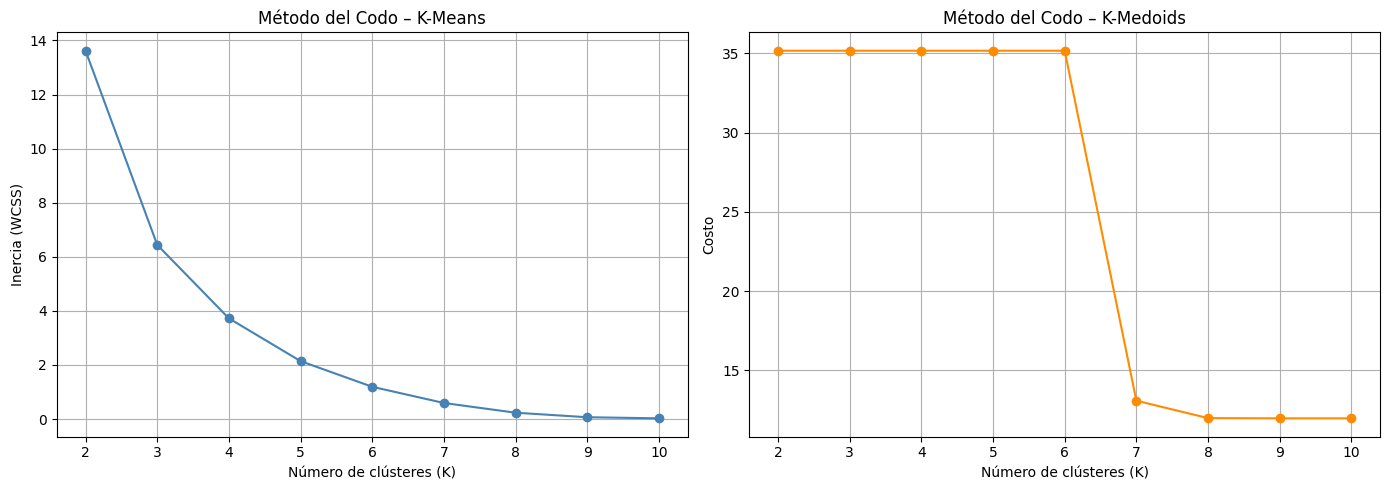

Gráfica guardada como elbow_plot.png


In [6]:
K_range = range(2, 11)

# K-means: inercia
inertias_km = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias_km.append(km.inertia_)

# K-medoids: costo
costs_kmed = []
for k in K_range:
    kmed = KMedoids(n_clusters=k, random_state=42, max_iter=300)
    kmed.fit(X)
    costs_kmed.append(kmed.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias_km, marker='o', color='steelblue')
axes[0].set_title('Método del Codo – K-Means')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].grid(True)

axes[1].plot(list(K_range), costs_kmed, marker='o', color='darkorange')
axes[1].set_title('Método del Codo – K-Medoids')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Costo')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()
print('Gráfica guardada como elbow_plot.png')


Coeficiente de Silhouette


El Silhouette mide qué tan bien separados están los clústeres (valores cercanos a 1 = mejor). Lo graficamos para cada K y determinamos el K óptimo.

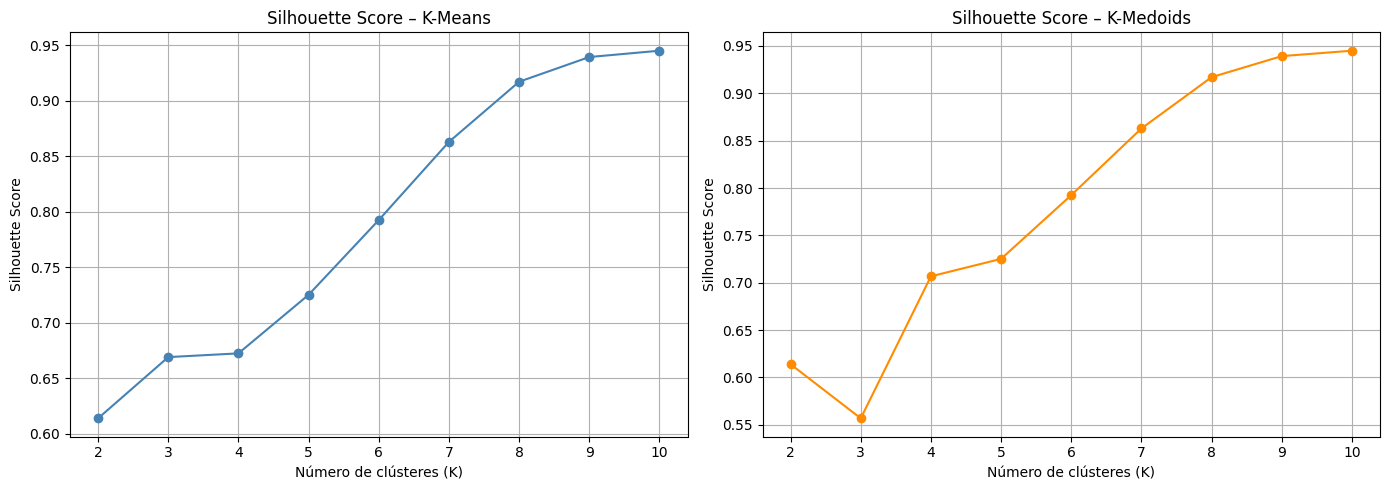

K óptimo K-Means   (Silhouette): 10  → score: 0.9450
K óptimo K-Medoids (Silhouette): 10 → score: 0.9450


In [8]:
sil_km   = []
sil_kmed = []

for k in K_range:
    # K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X)
    sil_km.append(silhouette_score(X, labels_km))

    # K-Medoids con método de inicialización más robusto
    try:
        kmed = KMedoids(n_clusters=k, method='pam', init='k-medoids++', random_state=42, max_iter=500)
        labels_kmed = kmed.fit_predict(X)
        n_unique = len(set(labels_kmed))
        if n_unique < 2:
            raise ValueError(f"Solo {n_unique} clúster(es) generados para K={k}")
        sil_kmed.append(silhouette_score(X, labels_kmed))
    except Exception as e:
        print(f"K={k} omitido en K-Medoids: {e}")
        sil_kmed.append(None)

# Filtrar Nones para graficar
k_list     = list(K_range)
sil_kmed_valid = [(k, s) for k, s in zip(k_list, sil_kmed) if s is not None]
k_valid    = [x[0] for x in sil_kmed_valid]
s_valid    = [x[1] for x in sil_kmed_valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_list, sil_km, marker='o', color='steelblue')
axes[0].set_title('Silhouette Score – K-Means')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True)

axes[1].plot(k_valid, s_valid, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score – K-Medoids')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150)
plt.show()

k_opt_km   = k_list[np.argmax(sil_km)]
k_opt_kmed = k_valid[np.argmax(s_valid)] if s_valid else k_opt_km

print(f'K óptimo K-Means   (Silhouette): {k_opt_km}  → score: {max(sil_km):.4f}')
print(f'K óptimo K-Medoids (Silhouette): {k_opt_kmed} → score: {max(s_valid):.4f}')

Etiquetado


Usamos el K óptimo determinado por Silhouette para etiquetar cada muestra de malware.

In [10]:
K_FINAL = k_opt_km

km_final   = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
kmed_final = KMedoids(n_clusters=K_FINAL, random_state=42, max_iter=300)

df['cluster_kmeans']   = km_final.fit_predict(X)
df['cluster_kmedoids'] = kmed_final.fit_predict(X)

print(df[['Hash', 'cluster_kmeans', 'cluster_kmedoids']].to_string())

df.to_csv('labeled.csv')
print('\nDataset etiquetado guardado como labeled.csv')

                                        Hash  cluster_kmeans  cluster_kmedoids
0           F6655E39465C2FF5B016980D918EA028               0                 0
1   FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2               3                 9
2           65018CD542145A3792BA09985734C12A               2                 9
3           6FAA4740F99408D4D2DDDD0B09BBDEFD               3                 9
4           F8437E44748D2C3FCF84019766F4E6DC               3                 9
5      B98hX8E8622C393D7E832D39E620EAD5D3B49               7                 6
6        SAM_B659D71AE168E774FAAF38DB30F4A84               9                 5
7      POL55_A4F1ECC4D25B33395196B5D51A06790               9                 5
8       BVJ2D9FBF759F527AF373E34673DC3ACA462               3                 9
9      AAAz2E1B6940985A23E5639450F8391820655               6                 5
10     VBMM9_149B7BD7218AAB4E257D28469FDDB0D               8                 5
11      NBV_8B75BCBFF174C25A0161F30758509A44        

/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 4 is empty! self.labels_[self.medoid_indices_[4]] may not be labeled with its corresponding cluster (4).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn_extra/cluster/_k_medoids.py:329: UserWarning: Cluster 7 